# Replacement analysis

Updated as of Sept. 23. This notebook analyzes the cleaned replacements data. 

Subset data through March
- create a subset through March 2025 to match with timeframe of LSI
  
Create a summary file by community area
- this section prepares the data for the replacement rate analysis
- calculate the estimated number of service lines requiring replacement in 2021
- replacement rate is defined as % of service lines requiring replacement in 2021 that have been replaced since 2021
- Exported to csv as total_replacement_rate_by_cca.csv

Correlations
- TK

In [118]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

In [119]:

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [120]:
# load cleaned replacements data
df = pd.read_csv('../processed/replacements_cleaned_updated_camupdate.csv')
df.head(2)

,Public or Consumer,Work Address,Status,Ward,Date Completed,program,ZIP_1,Type of Service,completed_year,completed_month_year,completed_day,clean_address,program_clean_address,full_address,row,classification_for_entire_service_line,stnum1,stnum2,stdir,stname,sttype,zip_2,geoid,matched_address,m_is_intersection,_merge,lat,long,GEOID_2,GEOIDFQ,tract_comm_2,NAME,NAMELSAD,completed_day_full
0,CONSUMER,8111 S STEWART AVE,Completed,6.0,2025-12-18,Daycare,60620.0,Daycares,2025,Dec-25,18-Dec,8111 S STEWART AVE,Daycare 8111 S STEWART AVE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only,41.746932,-87.634123,1.703184e+10,1400000US17031842400,44.0,8424.0,Census Tract 8424,2025-12-18
1,CONSUMER,7933 S PRINCETON AVE,Completed,17.0,2025-12-12,Breaks Leaks,60620.0,NaN,2025,Dec-25,12-Dec,7933 S PRINCETON AVE,Breaks Leaks 7933 S PRINCETON AVE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only,41.750209,-87.631788,1.703184e+10,1400000US17031842400,44.0,8424.0,Census Tract 8424,2025-12-12


In [121]:
df.columns

Index(['Public or Consumer', 'Work Address', 'Status', 'Ward',
       'Date Completed', 'program', 'ZIP_1', 'Type of Service',
       'completed_year', 'completed_month_year', 'completed_day',
       'clean_address', 'program_clean_address', 'full_address', 'row',
       'classification_for_entire_service_line', 'stnum1', 'stnum2', 'stdir',
       'stname', 'sttype', 'zip_2', 'geoid', 'matched_address',
       'm_is_intersection', '_merge', 'lat', 'long', 'GEOID_2', 'GEOIDFQ',
       'tract_comm_2', 'NAME', 'NAMELSAD', 'completed_day_full'],
      dtype='str')

In [122]:
df['Community Area'] = df['tract_comm_2']
df['Community Area'] = df['Community Area'].astype(str)
df['Community Area'] = df['Community Area'].str.replace(".0","")

In [123]:
df['tract_comm_2'] = df['tract_comm_2'].astype(str)
df['tract_comm_2'] = df['tract_comm_2'].str.replace(".0","")
df['NAME'] = df['NAME'].astype(str)
df['NAME'] = df['NAME'].str.replace(".0","")
df['geoid'] = df['geoid'].astype(str)
df['geoid'] = df['geoid'].str.replace(".0","")
df['GEOID_2'] = df['GEOID_2'].astype(str)
df['GEOID_2'] = df['GEOID_2'].str.replace(".0","")

In [124]:
display(df.head())

,Public or Consumer,Work Address,Status,Ward,Date Completed,program,ZIP_1,Type of Service,completed_year,completed_month_year,completed_day,clean_address,program_clean_address,full_address,row,classification_for_entire_service_line,stnum1,stnum2,stdir,stname,sttype,zip_2,geoid,matched_address,m_is_intersection,_merge,lat,long,GEOID_2,GEOIDFQ,tract_comm_2,NAME,NAMELSAD,completed_day_full,Community Area
0,CONSUMER,8111 S STEWART AVE,Completed,6.0,2025-12-18,Daycare,60620.0,Daycares,2025,Dec-25,18-Dec,8111 S STEWART AVE,Daycare 8111 S STEWART AVE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only,41.746932,-87.634123,17031842400,1400000US17031842400,44,8424,Census Tract 8424,2025-12-18,44
1,CONSUMER,7933 S PRINCETON AVE,Completed,17.0,2025-12-12,Breaks Leaks,60620.0,NaN,2025,Dec-25,12-Dec,7933 S PRINCETON AVE,Breaks Leaks 7933 S PRINCETON AVE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only,41.750209,-87.631788,17031842400,1400000US17031842400,44,8424,Census Tract 8424,2025-12-12,44
2,BOTH AS REQUIRED,7936 S NORMAL AVE,Completed,6.0,2025-12-11,Equity,60620.0,NaN,2025,Dec-25,11-Dec,7936 S NORMAL AVE,Equity 7936 S NORMAL AVE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only,41.749710,-87.636778,17031842400,1400000US17031842400,44,8424,Census Tract 8424,2025-12-11,44
3,PUBLIC,8042 S NORMAL AVE,Completed,6.0,2025-10-17,Daycare,60620.0,NaN,2025,Oct-25,17-Oct,8042 S NORMAL AVE,Daycare 8042 S NORMAL AVE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only,41.748064,-87.636733,17031842400,1400000US17031842400,44,8424,Census Tract 8424,2025-10-17,44
4,PUBLIC,7922 S LA SALLE ST,Completed,17.0,2025-09-29,Breaks Leaks,60620.0,NaN,2025,Sep-25,29-Sep,7922 S LA SALLE ST,Breaks Leaks 7922 S LA SALLE ST,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only,41.750445,-87.628310,17031842400,1400000US17031842400,44,8424,Census Tract 8424,2025-09-29,44


In [168]:
df.dtypes

Public or Consumer                            str
Work Address                                  str
Status                                        str
Ward                                      float64
Date Completed                                str
program                                       str
ZIP_1                                     float64
Type of Service                               str
completed_year                                str
completed_month_year                          str
completed_day                                 str
clean_address                                 str
program_clean_address                         str
full_address                                  str
row                                       float64
classification_for_entire_service_line        str
stnum1                                    float64
stnum2                                    float64
stdir                                         str
stname                                        str


## Subset data through March

In [125]:
mask = (df['completed_day_full'] < '2025-04-01') 
df_thru_march = df.loc[mask].copy()

In [126]:
print(len(df_thru_march))

10379


## Subset data to see if its on track this year

In [127]:
df[df['completed_year']==2024].groupby('completed_month_year').size().reset_index()

,completed_month_year,0
0,Apr-24,477
1,Aug-24,452
2,Dec-24,567
3,Feb-24,283
4,Jan-24,213
5,Jul-24,368
6,Jun-24,324
7,Mar-24,345
8,May-24,305
9,Nov-24,517


In [128]:
214+284+345+479+305+325+368+454

2774

In [129]:
df_thru_2024_ytd = df[df['completed_year']==2024]

In [130]:
print(len(df_thru_2024_ytd))

4877


## Totals by program and year

In [131]:
df.groupby('program').size()

program
Block Level LSLR             511
Breaks Leaks                9089
CIP Sewer and Water Main    1807
Daycare                      420
Equity                      2152
Homeowner Initiated         1085
dtype: int64

In [132]:
df_thru_march.groupby('program').size()

program
Block Level LSLR             127
Breaks Leaks                6261
CIP Sewer and Water Main     915
Daycare                      293
Equity                      1914
Homeowner Initiated          869
dtype: int64

In [133]:
g = df.groupby('program').size().reset_index()
g['pct'] = (g[0]/len(df))*100
g

,program,0,pct
0,Block Level LSLR,511,3.392193
1,Breaks Leaks,9089,60.335900
2,CIP Sewer and Water Main,1807,11.995486
3,Daycare,420,2.788104
4,Equity,2152,14.285714
5,Homeowner Initiated,1085,7.202602


In [134]:
df.groupby('completed_year').size()

completed_year
2021      27
2022     346
2023    3860
2024    4877
2025    5954
dtype: int64

Look at replacements by month by program to see if targeted ones like equity haven't ramped up as fast.

In [135]:
# replacements by month by program
by_month_by_program = df.groupby(['completed_month_year', 'program'],dropna=False).size().reset_index(name='replacements')

by_month_by_program = by_month_by_program.fillna(0)
by_month_by_program['completed_month_year'] = pd.to_datetime(by_month_by_program['completed_month_year'])
by_month_by_program = by_month_by_program.sort_values('completed_month_year')
by_month_by_program.tail()

/var/folders/rg/8bhrngv90nq72kdc777j64v80000gt/T/ipykernel_32872/494028890.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  by_month_by_program['completed_month_year'] = pd.to_datetime(by_month_by_program['completed_month_year'])


,completed_month_year,program,replacements
58,1-12-25,Breaks Leaks,249
59,1-12-25,CIP Sewer and Water Main,184
60,1-12-25,Daycare,15
61,1-12-25,Equity,38
62,1-12-25,Homeowner Initiated,21


In [136]:
# check
by_month_by_program['replacements'].sum()

np.int64(15064)

In [137]:
# export
by_month_by_program.to_csv('../processed/replacements_by_month_by_program_thru_aug.csv',index=False)

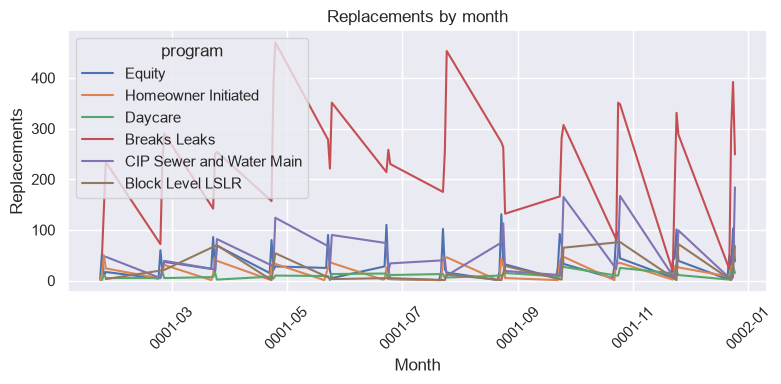

In [138]:
# plot on multi-line charts

by_month_by_program.drop(by_month_by_program.tail(1).index,inplace=True) # drop nov date for viz

sns.set(style='darkgrid')

plt.figure(figsize=(8, 4))
sns.lineplot(data=by_month_by_program, x='completed_month_year', y='replacements', hue='program')

plt.xlabel('Month')
plt.ylabel('Replacements')
plt.title('Replacements by month')
plt.xticks(rotation=45)
plt.tight_layout()

And then by year and YTD for a finding for the story?

In [139]:
df['completed_year'] = df['completed_year'].astype(str)

In [140]:
# replacements by year by program
by_year_by_program = df.groupby(['completed_year', 'program']).size().reset_index(name='replacements')

by_year_by_program = by_year_by_program.fillna(0)
by_year_by_program = by_year_by_program.sort_values('completed_year')
by_year_by_program.tail()

,completed_year,program,replacements
18,2025,Block Level LSLR,478
19,2025,Breaks Leaks,3606
20,2025,CIP Sewer and Water Main,1060
21,2025,Daycare,139
23,2025,Homeowner Initiated,310


In [141]:
by_year_by_program

,completed_year,program,replacements
0,2021,Equity,22
1,2021,Homeowner Initiated,5
2,2022,Breaks Leaks,41
3,2022,Daycare,2
4,2022,Equity,275
5,2022,Homeowner Initiated,28
10,2023,Equity,964
9,2023,Daycare,117
11,2023,Homeowner Initiated,334
7,2023,Breaks Leaks,2087


## Create a summary file by community area

Find the denominator for the rate, the estimated total number of suspected lead service lines in 2021 by community area by adding the number of suspected lines as of March and the number replaced as of March.

In [142]:
# group by cca thru march
total_by_cca_program_thru_march = pd.pivot_table(df_thru_march,
              index='Community Area',
              columns='program',
              values='program_clean_address',
              aggfunc='count',
              dropna=False).reset_index()

total_by_cca_program_thru_march = total_by_cca_program_thru_march.fillna(0)
total_by_cca_program_thru_march['Community Area'] = total_by_cca_program_thru_march['Community Area'].str.upper()

# add total replaced
col_list = ['Block Level LSLR', 'Breaks Leaks', 'CIP Sewer and Water Main','Daycare', 'Equity', 'Homeowner Initiated']
total_by_cca_program_thru_march['total_replacements_thru_march'] = total_by_cca_program_thru_march[col_list].sum(axis=1)

total_by_cca_program_thru_march

program,Community Area,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,total_replacements_thru_march
0,0,0.0,7.0,0.0,0.0,4.0,0.0,11.0
1,1,0.0,34.0,27.0,0.0,10.0,8.0,79.0
2,10,0.0,216.0,63.0,0.0,34.0,10.0,323.0
3,11,0.0,111.0,1.0,0.0,21.0,10.0,143.0
4,12,0.0,61.0,42.0,0.0,9.0,10.0,122.0
5,13,0.0,69.0,0.0,0.0,14.0,9.0,92.0
6,14,0.0,113.0,45.0,0.0,15.0,22.0,195.0
7,15,0.0,242.0,35.0,0.0,62.0,34.0,373.0
8,16,0.0,126.0,0.0,0.0,26.0,38.0,190.0
9,17,0.0,160.0,0.0,0.0,31.0,6.0,197.0


In [143]:
# read in inventory data by cca
inv_cca = pd.read_csv('/Users/crodriguez/Documents/GitHub/lead-replacements/chicago_community_areas.csv')
inv_cca.head()

,community,area_num_1,GRR,L,NL,U,total,flag,lead_plus_suspected,requires_replacement,pct_lead,pct_grr,pct_suspected_lead,pct_lead_plus_suspected,pct_requires_replacement,pct_not_lead,N,Y,NA,pct_replaced,median_household_income,pct_poverty,pct_hispanic,pct_white_nonhispanic,pct_black_nonhispanic,pct_asian_nonhispanic,pct_minority
0,Rogers Park,1,129,746,836,2118,3829,False,2864,2993,19.5,3.4,55.3,74.8,78.2,21.8,3775,54,0,1.4,59552.907508,18.1,21.1,44.6,23.3,5.8,55.4
1,West Ridge,2,137,2920,1031,5931,10019,False,8851,8988,29.1,1.4,59.2,88.3,89.7,10.3,9899,119,1,1.2,71524.002706,17.4,21.9,38.7,11.7,21.8,61.3
2,Uptown,3,37,465,1370,1509,3381,False,1974,2011,13.8,1.1,44.6,58.4,59.5,40.5,3338,43,0,1.3,68443.897980,20.7,14.0,50.9,20.0,10.4,49.1
3,Lincoln Square,4,119,1864,1438,2703,6124,False,4567,4686,30.4,1.9,44.1,74.6,76.5,23.5,6014,110,0,1.8,93604.920261,9.6,19.8,60.9,4.4,9.2,39.1
4,North Center,5,126,1611,3125,2491,7353,False,4102,4228,21.9,1.7,33.9,55.8,57.5,42.5,7269,84,0,1.1,145156.056471,4.7,13.3,73.1,2.2,6.2,26.9


In [144]:
inv_cca.columns

Index(['community', 'area_num_1', 'GRR', 'L', 'NL', 'U', 'total', 'flag',
       'lead_plus_suspected', 'requires_replacement', 'pct_lead', 'pct_grr',
       'pct_suspected_lead', 'pct_lead_plus_suspected',
       'pct_requires_replacement', 'pct_not_lead', 'N', 'Y', 'NA',
       'pct_replaced', 'median_household_income', 'pct_poverty',
       'pct_hispanic', 'pct_white_nonhispanic', 'pct_black_nonhispanic',
       'pct_asian_nonhispanic', 'pct_minority'],
      dtype='str')

In [145]:
# merge
cca_analysis = pd.merge(total_by_cca_program_thru_march[['Community Area', 'total_replacements_thru_march']], inv_cca[['community', 'requires_replacement', 'pct_requires_replacement', 'total','Y', 'N', 'pct_replaced', 'pct_poverty',
                                                                 'pct_hispanic', 'pct_white_nonhispanic', 'pct_black_nonhispanic', 'pct_asian_nonhispanic',
                                                                 'pct_minority', 'median_household_income']],
                       left_on='Community Area', right_on=inv_cca['community'].str.upper(), how='right')

In [146]:
cca_analysis['total_suspected_2021'] = cca_analysis['requires_replacement'] + cca_analysis['total_replacements_thru_march']

In [147]:
cca_analysis.head()

,Community Area,total_replacements_thru_march,community,requires_replacement,pct_requires_replacement,total,Y,N,pct_replaced,pct_poverty,pct_hispanic,pct_white_nonhispanic,pct_black_nonhispanic,pct_asian_nonhispanic,pct_minority,median_household_income,total_suspected_2021
0,ROGERS PARK,NaN,Rogers Park,2993,78.2,3829,54,3775,1.4,18.1,21.1,44.6,23.3,5.8,55.4,59552.907508,NaN
1,WEST RIDGE,NaN,West Ridge,8988,89.7,10019,119,9899,1.2,17.4,21.9,38.7,11.7,21.8,61.3,71524.002706,NaN
2,UPTOWN,NaN,Uptown,2011,59.5,3381,43,3338,1.3,20.7,14.0,50.9,20.0,10.4,49.1,68443.897980,NaN
3,LINCOLN SQUARE,NaN,Lincoln Square,4686,76.5,6124,110,6014,1.8,9.6,19.8,60.9,4.4,9.2,39.1,93604.920261,NaN
4,NORTH CENTER,NaN,North Center,4228,57.5,7353,84,7269,1.1,4.7,13.3,73.1,2.2,6.2,26.9,145156.056471,NaN


Merge denominator info with replacements as of August

In [148]:
# group by cca thru aug
total_by_cca_program_thru_aug = pd.pivot_table(df,
              index='Community Area',
              columns='program',
              values='program_clean_address',
              aggfunc='count',
              dropna=False).reset_index()

total_by_cca_program_thru_aug = total_by_cca_program_thru_aug.fillna(0)
total_by_cca_program_thru_aug['Community Area'] = total_by_cca_program_thru_aug['Community Area'].str.upper()

# add total replaced
col_list = ['Block Level LSLR', 'Breaks Leaks', 'CIP Sewer and Water Main','Daycare', 'Equity', 'Homeowner Initiated']
total_by_cca_program_thru_aug['total_replacements_thru_aug'] = total_by_cca_program_thru_aug[col_list].sum(axis=1)

total_by_cca_program_thru_aug.tail(2)

program,Community Area,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,total_replacements_thru_aug
76,9,0.0,96.0,0.0,1.0,7.0,11.0,115.0
77,NaN,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [149]:
total_by_cca_program_thru_aug['total_replacements_thru_aug'].sum()

np.float64(15064.0)

In [150]:
# merge
cca_analysis = pd.merge(cca_analysis, total_by_cca_program_thru_aug, on='Community Area', how='left')

In [151]:
cca_analysis['total_replacements_thru_aug'].sum()

np.float64(0.0)

In [152]:
# calc rate
cca_analysis['pct_replaced_aug'] = cca_analysis['total_replacements_thru_aug']/cca_analysis['total_suspected_2021']

In [153]:
# calc pct requiring replacement in 2021
cca_analysis['pct_requiring_replacement_2021'] = cca_analysis['total_suspected_2021']/cca_analysis['total']

In [154]:
# categorize cca's with majority race
def majority_race(row):
    if row['pct_white_nonhispanic'] > 50:
        return 'white'
    elif row['pct_black_nonhispanic'] > 50:
        return 'black'
    elif row['pct_hispanic'] > 50:
        return 'latino'
    elif row['pct_asian_nonhispanic'] > 50:
        return 'asian'
    else:
        return 'no majority'

cca_analysis['majority_race'] = cca_analysis.apply(majority_race, axis=1)

In [155]:
cca_analysis.groupby('majority_race').size()

majority_race
asian           1
black          28
latino         19
no majority    10
white          19
dtype: int64

## Export as csv!

In [156]:
cca_analysis.to_csv('../processed/total_replacement_rate_by_cca_thru_aug.csv', index=False)

## Analysis by community area

Little correlation between communities/tracts that have rate of replacements and communities/tracts with the highest share of lines that require replacement.

<Axes: >

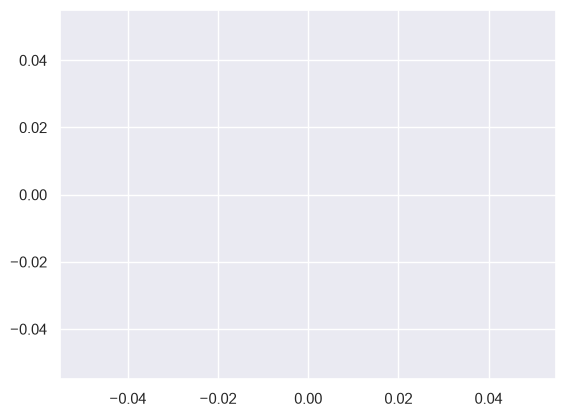

In [157]:
sns.scatterplot(data=cca_analysis, x='pct_requiring_replacement_2021', y='pct_replaced_aug')

In [158]:
print(cca_analysis['pct_requiring_replacement_2021'].corr(cca_analysis['pct_replaced_aug']))

nan


It's actually negatively linearly correlated

<Axes: >

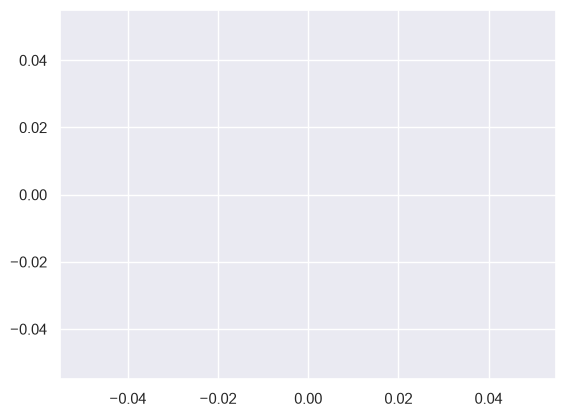

In [159]:
sns.scatterplot(data=cca_analysis, x='pct_requires_replacement', y='pct_replaced_aug')

In [160]:
print(cca_analysis['pct_requires_replacement'].corr(cca_analysis['pct_replaced_aug']))

nan


Majority black communities have the highest replacement rate, over the citywide rate, but majority latino communities are lagging behind majority white.

In [161]:
g = cca_analysis.groupby('majority_race')[['total_replacements_thru_aug', 'total_suspected_2021','total']].sum()
g['pct_replaced'] = g['total_replacements_thru_aug']/g['total_suspected_2021']
g['pct_requires_replacement_2021'] = g['total_suspected_2021']/g['total']
g

,total_replacements_thru_aug,total_suspected_2021,total,pct_replaced,pct_requires_replacement_2021
majority_race,,,,,
asian,0.0,0.0,1915,NaN,0.0
black,0.0,0.0,152964,NaN,0.0
latino,0.0,0.0,129217,NaN,0.0
no majority,0.0,0.0,76675,NaN,0.0
white,0.0,0.0,130174,NaN,0.0


## Maps by community area

In [162]:
# load cca chicago
cca = gpd.read_file('/Users/crodriguez/Documents/GitHub/lead-replacements/chicago_community_areas.geojson')

In [163]:
cca.head(2)

,community,area_num_1,GRR,L,NL,U,total,flag,lead_plus_suspected,requires_replacement,pct_lead,pct_grr,pct_suspected_lead,pct_lead_plus_suspected,pct_requires_replacement,pct_not_lead,N,Y,NA,pct_replaced,median_household_income,pct_poverty,pct_hispanic,pct_white_nonhispanic,pct_black_nonhispanic,pct_asian_nonhispanic,pct_minority,geometry
0,Rogers Park,1,129,746,836,2118,3829,False,2864,2993,19.5,3.4,55.3,74.8,78.2,21.8,3775,54,0,1.4,59552.907508,18.1,21.1,44.6,23.3,5.8,55.4,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,West Ridge,2,137,2920,1031,5931,10019,False,8851,8988,29.1,1.4,59.2,88.3,89.7,10.3,9899,119,1,1.2,71524.002706,17.4,21.9,38.7,11.7,21.8,61.3,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."


In [164]:
# merge with tract analysis
cca_map = pd.merge(cca, cca_analysis, left_on='community', right_on='Community Area', how='left')
print(len(cca_map))

77


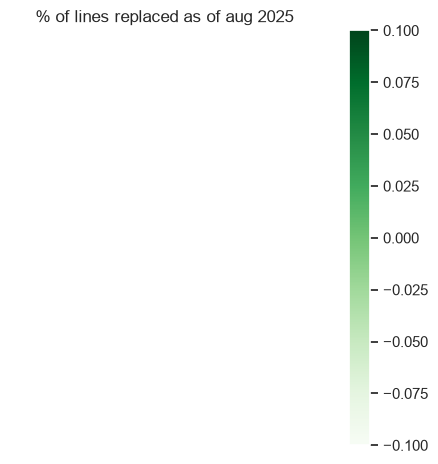

In [165]:
fig, ax = plt.subplots()

cca_map.plot(ax=ax, column=cca_map['pct_replaced_aug'] * 100, cmap='Greens', legend=True)
ax.set_title('% of lines replaced as of aug 2025')
ax.axis('off')
plt.tight_layout() # adjust layout
plt.show()

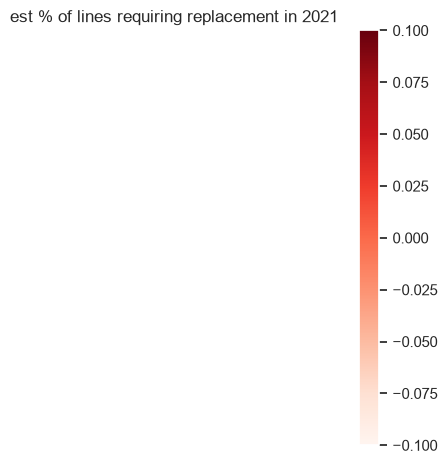

In [166]:
fig, ax = plt.subplots()

cca_map.plot(ax=ax, column='pct_requiring_replacement_2021', cmap='Reds', legend=True)
ax.set_title('est % of lines requiring replacement in 2021')
ax.axis('off')
plt.tight_layout() # adjust layout
plt.show()

KeyError: 'pct_requires_replacement'

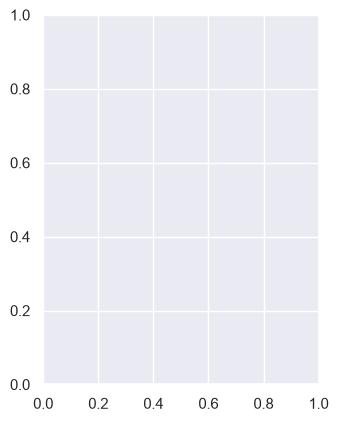

In [167]:
fig, ax = plt.subplots()

cca_map.plot(ax=ax, column='pct_requires_replacement', cmap='Reds', legend=True)
ax.set_title('% of lines requiring replacement as of 2025 inventory')
ax.axis('off')
plt.tight_layout() # adjust layout
plt.show()

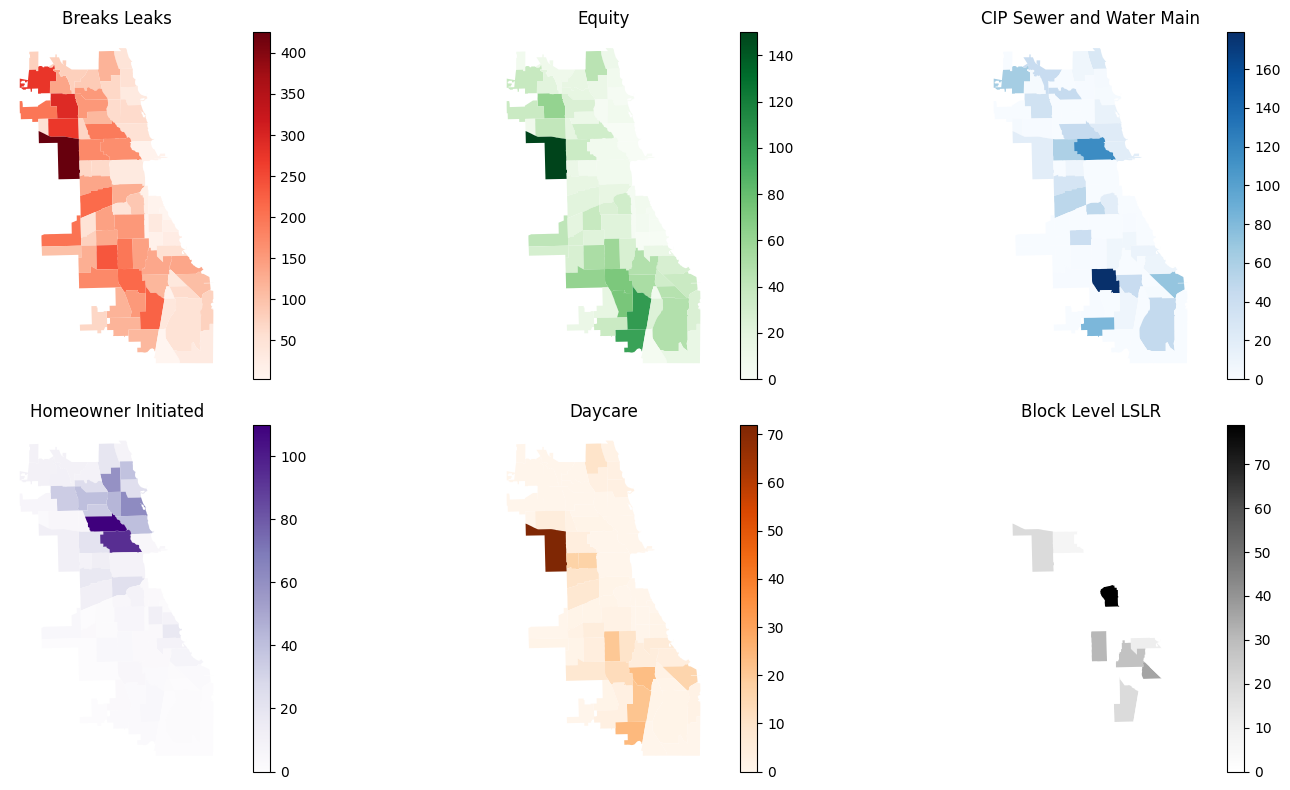

In [ ]:
# Create a figure with 6 subplots (2 rows, 3 columns)
fig, ax = plt.subplots(2, 3, figsize=(16, 8))

# Flatten axes for easy indexing
ax = ax.flatten()

# Plot on the first subplot
cca_map.plot(ax=ax[0], column='Breaks Leaks', cmap='Reds', legend=True)
ax[0].set_title('Breaks Leaks')

# Plot on the second subplot
cca_map.plot(ax=ax[1], column='Equity', cmap='Greens', legend=True)
ax[1].set_title('Equity')

# Plot on the third subplot
cca_map.plot(ax=ax[2], column='CIP Sewer and Water Main', cmap='Blues', legend=True)
ax[2].set_title('CIP Sewer and Water Main')

# Plot on the fourth subplot
cca_map.plot(ax=ax[3], column='Homeowner Initiated', cmap='Purples', legend=True)
ax[3].set_title('Homeowner Initiated')

cca_map.plot(ax=ax[4], column='Daycare', cmap='Oranges', legend=True)
ax[4].set_title('Daycare')

cca_map.plot(ax=ax[5], column='Block Level LSLR', cmap='Greys', legend=True)
ax[5].set_title('Block Level LSLR')

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[3].axis('off')
ax[4].axis('off')
ax[5].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Create a summary file by tract

In [169]:
# group by tract thru march
total_by_tract_program_thru_march = pd.pivot_table(df_thru_march,
              index='GEOID_2',
              columns='program',
              values='program_clean_address',
              aggfunc='count',
              dropna=False).reset_index()

total_by_tract_program_thru_march = total_by_tract_program_thru_march.fillna(0)

# add total replaced
col_list = ['Block Level LSLR', 'Breaks Leaks', 'CIP Sewer and Water Main','Daycare', 'Equity', 'Homeowner Initiated']
total_by_tract_program_thru_march['total_replacements_thru_march'] = total_by_tract_program_thru_march[col_list].sum(axis=1)

total_by_tract_program_thru_march

program,GEOID_2,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,total_replacements_thru_march
0,17031010100,0.0,3.0,5.0,0.0,1.0,0.0,9.0
1,17031010201,0.0,2.0,0.0,0.0,2.0,0.0,4.0
2,17031010202,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,17031010300,0.0,5.0,22.0,0.0,0.0,2.0,29.0
4,17031010400,0.0,2.0,0.0,0.0,0.0,0.0,2.0
5,17031010501,0.0,3.0,0.0,0.0,1.0,0.0,4.0
6,17031010502,0.0,3.0,0.0,0.0,0.0,0.0,3.0
7,17031010503,0.0,4.0,0.0,0.0,0.0,2.0,6.0
8,17031010600,0.0,5.0,0.0,0.0,1.0,2.0,8.0
9,17031010701,0.0,3.0,0.0,0.0,4.0,0.0,7.0


In [170]:
# check, should be 10392
total_by_tract_program_thru_march['total_replacements_thru_march'].sum()

np.float64(10379.0)

In [180]:
# read in inventory data by tract
inv_tracts = pd.read_csv('/Users/crodriguez/Documents/GitHub/lead-replacements/chicago_tracts_filled.csv')
inv_tracts.head()

,geoid,pct_poverty,median_household_income,pct_hispanic,pct_black_nonhispanic,pct_white_nonhispanic,pct_asian_nonhispanic,pct_minority,households,pct_limited_or_no_english,GRR,L,NL,U,total,flag,lead_plus_suspected,requires_replacement,pct_lead,pct_grr,pct_suspected_lead,pct_lead_plus_suspected,pct_requires_replacement,pct_not_lead,N,Y,pct_replaced
0,17031030101,17.5,49132.0,9.1,20.2,47.1,17.8,52.9,2162,6.4,0.0,5.0,29.0,28.0,62.0,False,33.0,33.0,8.1,0.0,45.2,53.2,53.2,46.8,62.0,0.0,0.0
1,17031030701,19.7,51625.0,12.9,33.2,45.7,5.6,54.3,894,1.9,0.0,3.0,26.0,14.0,43.0,False,17.0,17.0,7.0,0.0,32.6,39.5,39.5,60.5,42.0,1.0,2.3
2,17031070103,13.4,76477.0,6.3,8.7,69.2,6.1,30.8,1133,0.0,0.0,28.0,27.0,32.0,87.0,False,60.0,60.0,32.2,0.0,36.8,69.0,69.0,31.0,84.0,3.0,3.4
3,17031770602,3.8,85913.0,54.8,1.0,32.7,8.7,67.3,1541,18.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17031841200,14.0,62819.0,83.0,2.5,13.6,0.0,86.4,1796,13.3,8.0,73.0,115.0,550.0,746.0,False,623.0,631.0,9.8,1.1,73.7,83.5,84.6,15.4,734.0,12.0,1.6


In [181]:
inv_tracts.geoid.dtype

dtype('int64')

In [182]:
inv_tracts['geoid'] = inv_tracts['geoid'].astype(str)

In [183]:
# merge
tract_analysis = pd.merge(total_by_tract_program_thru_march[['GEOID_2', 'total_replacements_thru_march']], inv_tracts[['geoid', 'requires_replacement', 'pct_requires_replacement', 'total','Y', 'N', 'pct_replaced', 'pct_poverty',
                                                                 'pct_hispanic', 'pct_white_nonhispanic', 'pct_black_nonhispanic', 'pct_asian_nonhispanic',
                                                                 'pct_minority', 'median_household_income']],
                       left_on='GEOID_2', right_on='geoid', how='right', indicator=True)

In [184]:
# check, should be 10392
tract_analysis['total_replacements_thru_march'].sum()

np.float64(10378.0)

In [185]:
# should be 491,384
tract_analysis['total'].sum()

np.float64(491406.0)

In [186]:
tract_analysis.head(2)

,GEOID_2,total_replacements_thru_march,geoid,requires_replacement,pct_requires_replacement,total,Y,N,pct_replaced,pct_poverty,pct_hispanic,pct_white_nonhispanic,pct_black_nonhispanic,pct_asian_nonhispanic,pct_minority,median_household_income,_merge
0,NaN,NaN,17031030101,33.0,53.2,62.0,0.0,62.0,0.0,17.5,9.1,47.1,20.2,17.8,52.9,49132.0,right_only
1,17031030701,1.0,17031030701,17.0,39.5,43.0,1.0,42.0,2.3,19.7,12.9,45.7,33.2,5.6,54.3,51625.0,both


In [187]:
tract_analysis['total_suspected_2021'] = tract_analysis['requires_replacement'] + tract_analysis['total_replacements_thru_march']

In [188]:
tract_analysis.tail(2)

,GEOID_2,total_replacements_thru_march,geoid,requires_replacement,pct_requires_replacement,total,Y,N,pct_replaced,pct_poverty,pct_hispanic,pct_white_nonhispanic,pct_black_nonhispanic,pct_asian_nonhispanic,pct_minority,median_household_income,_merge,total_suspected_2021
801,17031550100,22.0,17031550100,1777.0,88.8,2002.0,21.0,1981.0,1.0,12.6,48.6,31.3,18.3,1.3,68.7,52174.0,both,1799.0
802,17031710300,10.0,17031710300,251.0,91.9,273.0,6.0,267.0,2.2,17.0,3.5,0.0,95.6,0.9,100.0,54886.0,both,261.0


In [189]:
# merge denominator with replacements as of aug

# group by tract thru aug
total_by_tract_program_thru_aug = pd.pivot_table(df,
              index='GEOID_2',
              columns='program',
              values='program_clean_address',
              aggfunc='count',
              dropna=False).reset_index()

total_by_tract_program_thru_aug = total_by_tract_program_thru_aug.fillna(0)

# add total replaced
col_list = ['Block Level LSLR', 'Breaks Leaks', 'CIP Sewer and Water Main','Daycare', 'Equity', 'Homeowner Initiated']
total_by_tract_program_thru_aug['total_replacements_thru_aug'] = total_by_tract_program_thru_aug[col_list].sum(axis=1)

total_by_tract_program_thru_aug.tail(2)

program,GEOID_2,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,total_replacements_thru_aug
748,17031844700,0.0,20.0,29.0,0.0,4.0,2.0,55.0
749,0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [190]:
# check, should equal 12,652
total_by_tract_program_thru_aug['total_replacements_thru_aug'].sum()

np.float64(15064.0)

In [192]:
# merge
tract_analysis = pd.merge(tract_analysis, total_by_tract_program_thru_aug, on='GEOID_2', how='outer')

In [193]:
tract_analysis['total_replacements_thru_aug'].sum()

np.float64(15064.0)

In [194]:
tract_analysis['total'].sum()

np.float64(491406.0)

In [195]:
# calc rate
tract_analysis['pct_replaced_aug'] = tract_analysis['total_replacements_thru_aug']/tract_analysis['total_suspected_2021']

In [196]:
# calc pct requiring replacement in 2021
tract_analysis['pct_requiring_replacement_2021'] = tract_analysis['total_suspected_2021']/tract_analysis['total']

In [197]:
# categorize cca's with majority race
tract_analysis['majority_race'] = tract_analysis.apply(majority_race, axis=1)

In [198]:
tract_analysis.groupby('majority_race').size()

majority_race
asian            9
black          263
latino         168
no majority    141
white          239
dtype: int64

## Export as csv!

In [199]:
tract_analysis.to_csv('../processed/total_replacement_rate_by_tract_thru_aug.csv', index=False)

In [200]:
inv_tracts['total'].sum()

np.float64(491406.0)

In [201]:
tract_analysis['total'].sum()

np.float64(491406.0)

### Create a summary file by tract just for counts

In [202]:
tracts_by_count = pd.pivot_table(df,
              index='GEOID_2',
              columns='program',
              values='program_clean_address',
              aggfunc='count',
              dropna=False).reset_index()

tracts_by_count = tracts_by_count.fillna(0)

In [203]:
tracts_by_count.to_csv('../processed/replacement_count_by_tract.csv', index=False)

## Analysis by tract

<Axes: xlabel='pct_requiring_replacement_2021', ylabel='pct_replaced_aug'>

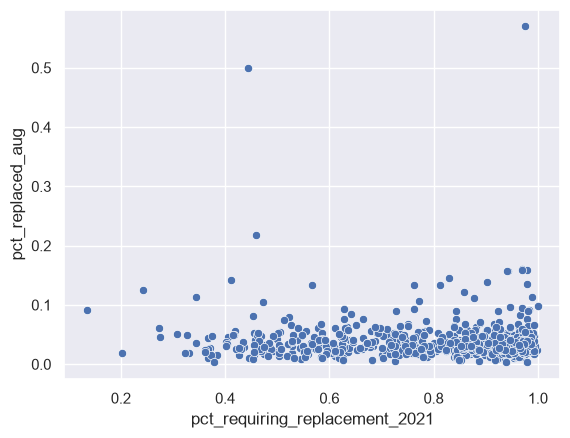

In [204]:
sns.scatterplot(data=tract_analysis, x='pct_requiring_replacement_2021', y='pct_replaced_aug')

<Axes: xlabel='pct_requiring_replacement_2021', ylabel='pct_replaced_aug'>

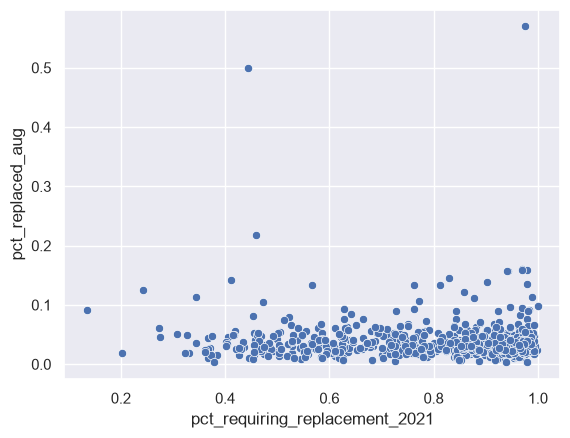

In [206]:
# remove outlier tract with 2/4 suspected replaced
sns.scatterplot(data=tract_analysis[tract_analysis['GEOID_2'] != 17031063303], x='pct_requiring_replacement_2021', y='pct_replaced_aug')

In [207]:
print(tract_analysis['pct_requiring_replacement_2021'].corr(tract_analysis['pct_replaced_aug']))

-0.06038195281259238


<Axes: xlabel='pct_minority', ylabel='pct_replaced_aug'>

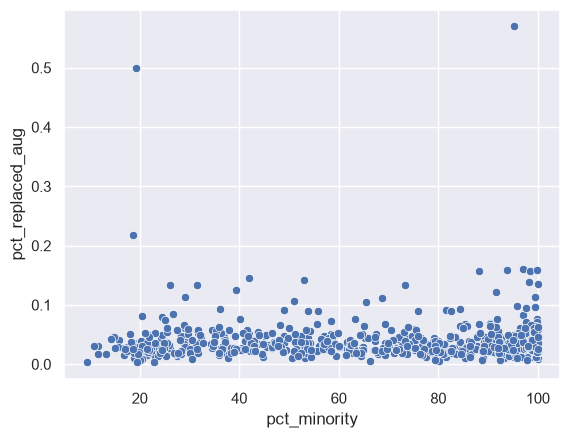

In [209]:
sns.scatterplot(data=tract_analysis[tract_analysis['GEOID_2'] != 17031063303], x='pct_minority', y='pct_replaced_aug')

In [210]:
print(tract_analysis['pct_minority'].corr(tract_analysis['pct_replaced_aug']))

-0.002617181243063146


Slight negative correlation with income, meaning lower income tracts have a higher replacement rate.

<Axes: xlabel='median_household_income', ylabel='pct_replaced_aug'>

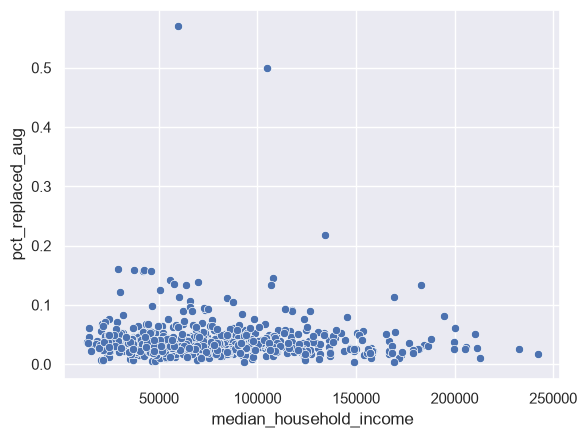

In [211]:
sns.scatterplot(data=tract_analysis[tract_analysis['GEOID_2'] != 17031063303], x='median_household_income', y='pct_replaced_aug')

In [212]:
print(tract_analysis['median_household_income'].corr(tract_analysis['pct_replaced_aug']))

-0.029200534354717804


In [213]:
g = tract_analysis.groupby('majority_race')[['total_replacements_thru_aug', 'total_suspected_2021','total']].sum()
g['pct_replaced'] = g['total_replacements_thru_aug']/g['total_suspected_2021']
g['pct_requires_replacement_2021'] = g['total_suspected_2021']/g['total']
g

,total_replacements_thru_aug,total_suspected_2021,total,pct_replaced,pct_requires_replacement_2021
majority_race,,,,,
asian,178.0,3176.0,4705.0,0.056045,0.675027
black,5659.0,144590.0,158878.0,0.039138,0.910069
latino,3769.0,116085.0,124029.0,0.032468,0.935950
no majority,2216.0,58125.0,71489.0,0.038125,0.813062
white,3242.0,98262.0,132305.0,0.032993,0.742693


## Maps by tract

In [214]:
# load 2020 tracts for chicago
tracts = gpd.read_file('/Users/crodriguez/Documents/GitHub/lead-replacements/chi_tracts.geojson')

In [220]:
tracts['GEOID'] = tracts['GEOID'].astype(str)

In [221]:
len(tracts)

795

In [222]:
# merge with tract analysis
tract_map = pd.merge(tracts, tract_analysis, left_on='GEOID', right_on='GEOID_2', how='left')

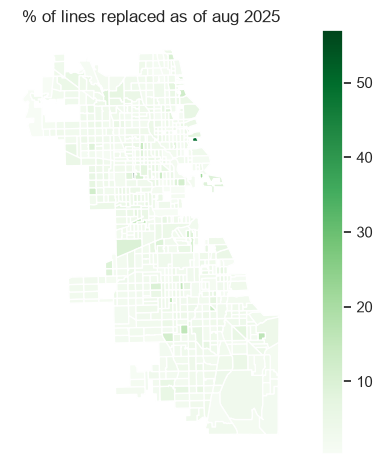

In [223]:
fig, ax = plt.subplots()

tract_map.plot(ax=ax, column=tract_map['pct_replaced_aug']*100, cmap='Greens', legend=True)
ax.set_title('% of lines replaced as of aug 2025')
ax.axis('off')
plt.tight_layout() # adjust layout
plt.show()

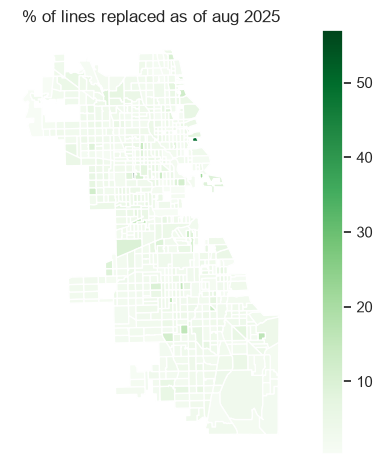

In [224]:
# remove outlier 
# https://censusreporter.org/profiles/14000US17031063303-census-tract-63303-cook-il/
fig, ax = plt.subplots()

tract_map_no_outlier = tract_map[tract_map['GEOID_2'] != 17031063303].copy()

tract_map_no_outlier.plot(ax=ax, column=tract_map_no_outlier['pct_replaced_aug']*100, cmap='Greens', legend=True)
ax.set_title('% of lines replaced as of aug 2025')
ax.axis('off')
plt.tight_layout() # adjust layout
plt.show()

In [225]:
# map histogram of pct replaced by census tract
tract_analysis['pct_replaced_aug'].describe()

count    733.000000
mean       0.038791
std        0.035003
min        0.002959
25%        0.024482
50%        0.032184
75%        0.043521
max        0.569620
Name: pct_replaced_aug, dtype: float64

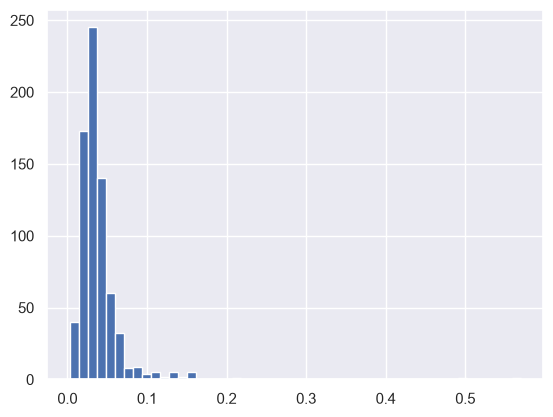

In [226]:
n_bins = 50

tract_analysis['pct_replaced_aug'].hist(bins=n_bins)

plt.show()

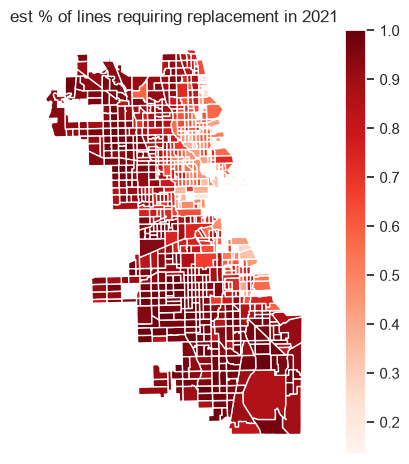

In [227]:
fig, ax = plt.subplots()

tract_map.plot(ax=ax, column='pct_requiring_replacement_2021', cmap='Reds', legend=True)
ax.set_title('est % of lines requiring replacement in 2021')
ax.axis('off')
plt.tight_layout() # adjust layout
plt.show()

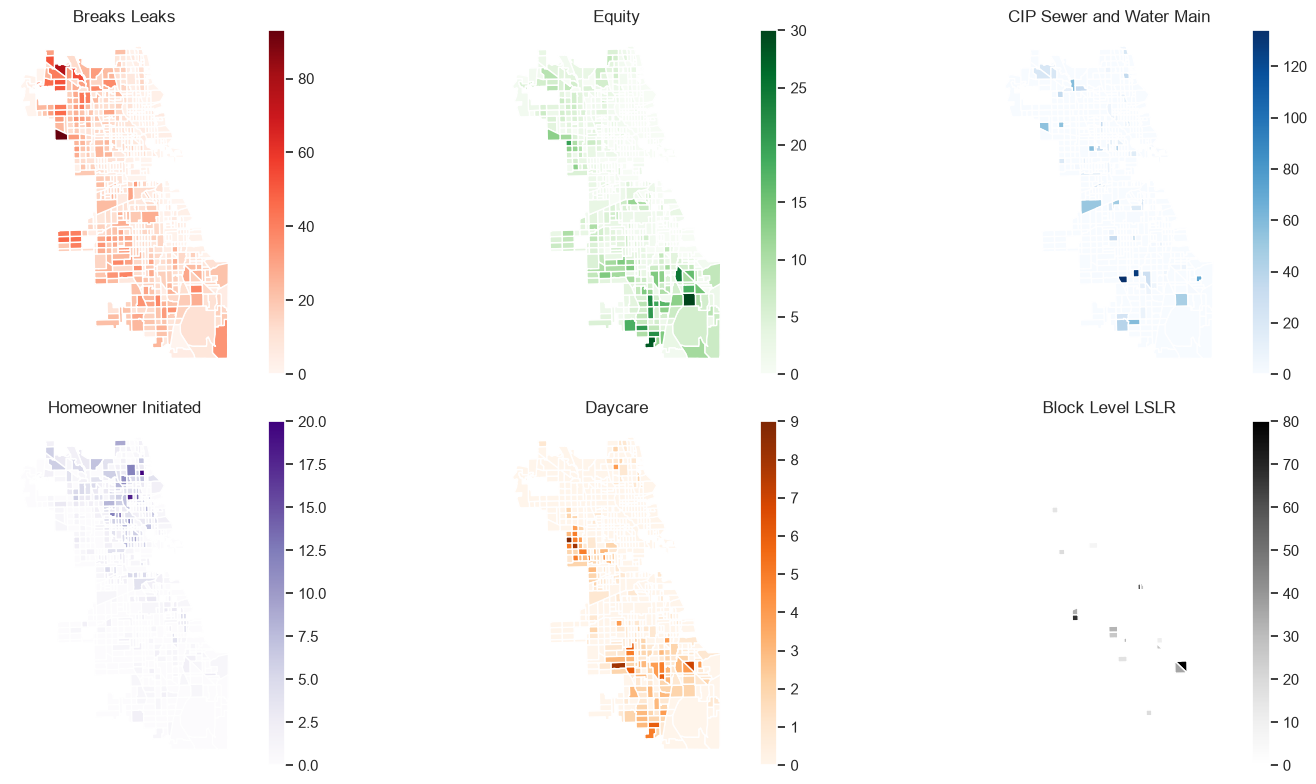

In [228]:
# Create a figure with 6 subplots (2 rows, 3 columns)
fig, ax = plt.subplots(2, 3, figsize=(16, 8))

# Flatten axes for easy indexing
ax = ax.flatten()

# Plot on the first subplot
tract_map.plot(ax=ax[0], column='Breaks Leaks', cmap='Reds', legend=True)
ax[0].set_title('Breaks Leaks')

# Plot on the second subplot
tract_map.plot(ax=ax[1], column='Equity', cmap='Greens', legend=True)
ax[1].set_title('Equity')

# Plot on the third subplot
tract_map.plot(ax=ax[2], column='CIP Sewer and Water Main', cmap='Blues', legend=True)
ax[2].set_title('CIP Sewer and Water Main')

# Plot on the fourth subplot
tract_map.plot(ax=ax[3], column='Homeowner Initiated', cmap='Purples', legend=True)
ax[3].set_title('Homeowner Initiated')

tract_map.plot(ax=ax[4], column='Daycare', cmap='Oranges', legend=True)
ax[4].set_title('Daycare')

tract_map.plot(ax=ax[5], column='Block Level LSLR', cmap='Greys', legend=True)
ax[5].set_title('Block Level LSLR')

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[3].axis('off')
ax[4].axis('off')
ax[5].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

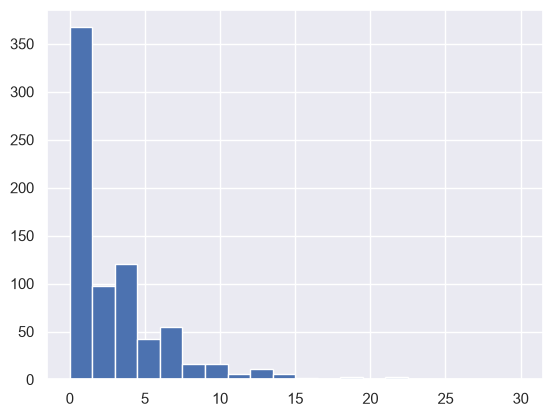

In [229]:
n_bins = 20

tract_analysis['Equity'].hist(bins=n_bins)

plt.show()

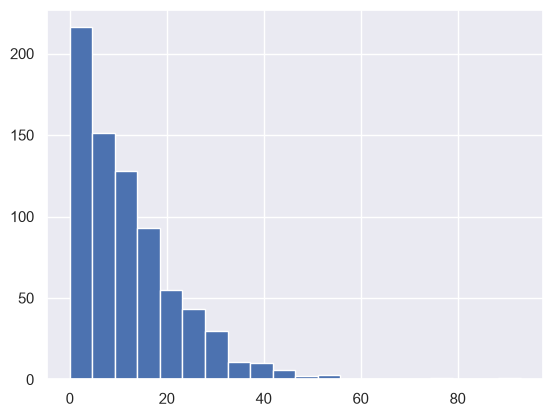

In [230]:
n_bins = 20

tract_analysis['Breaks Leaks'].hist(bins=n_bins)

plt.show()

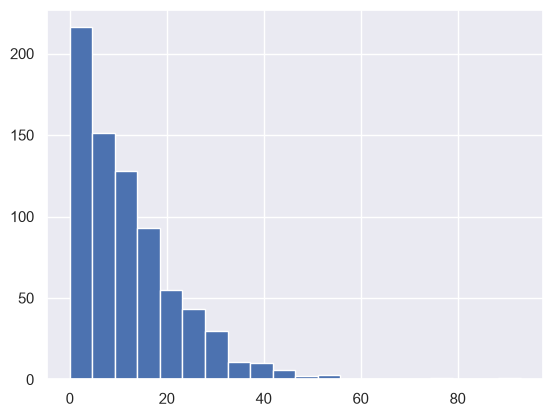

In [231]:
n_bins = 20

tract_analysis['Breaks Leaks'].hist(bins=n_bins)

plt.show()

## Analysis of most common replacement by tract or majority replacement by tract

In [232]:
dft = pd.read_csv('../processed/replacement_count_by_tract.csv')

In [233]:
dft.head()

,GEOID_2,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated
0,17031010100,0.0,3.0,5.0,0.0,1.0,0.0
1,17031010201,0.0,2.0,0.0,1.0,2.0,0.0
2,17031010202,0.0,2.0,0.0,0.0,1.0,0.0
3,17031010300,0.0,6.0,22.0,0.0,0.0,2.0
4,17031010400,0.0,2.0,0.0,0.0,0.0,1.0


In [234]:
len(dft)

750

In [235]:
cols = ["Block Level LSLR","Breaks Leaks","CIP Sewer and Water Main","Daycare","Equity","Homeowner Initiated"]
dft["max"] = dft[cols].idxmax(axis=1)

In [236]:
dft.tail()

,GEOID_2,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,max
745,17031843800,0.0,14.0,0.0,0.0,1.0,0.0,Breaks Leaks
746,17031843900,0.0,3.0,0.0,1.0,0.0,0.0,Breaks Leaks
747,17031844600,0.0,1.0,0.0,0.0,0.0,3.0,Homeowner Initiated
748,17031844700,0.0,20.0,29.0,0.0,4.0,2.0,CIP Sewer and Water Main
749,0,0.0,0.0,0.0,0.0,0.0,1.0,Homeowner Initiated


In [237]:
def get_maxes(row):
    max_val = row[cols].max()
    return [col for col in cols if row[col] == max_val]

dft["maxes"] = dft.apply(get_maxes, axis=1)

In [238]:
dft.head()

,GEOID_2,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,max,maxes
0,17031010100,0.0,3.0,5.0,0.0,1.0,0.0,CIP Sewer and Water Main,[CIP Sewer and Water Main]
1,17031010201,0.0,2.0,0.0,1.0,2.0,0.0,Breaks Leaks,"[Breaks Leaks, Equity]"
2,17031010202,0.0,2.0,0.0,0.0,1.0,0.0,Breaks Leaks,[Breaks Leaks]
3,17031010300,0.0,6.0,22.0,0.0,0.0,2.0,CIP Sewer and Water Main,[CIP Sewer and Water Main]
4,17031010400,0.0,2.0,0.0,0.0,0.0,1.0,Breaks Leaks,[Breaks Leaks]


In [239]:
dft.to_csv('../processed/max_program_by_tract.csv', index=False)

In [240]:
dft['GEOID_2'] = dft['GEOID_2'].astype(str)

In [241]:
# merge with geojson
dft_map = pd.merge(tracts, dft, left_on='GEOID', right_on='GEOID_2', how='left')
dft_map['maxes_str'] = dft_map['maxes'].astype(str)

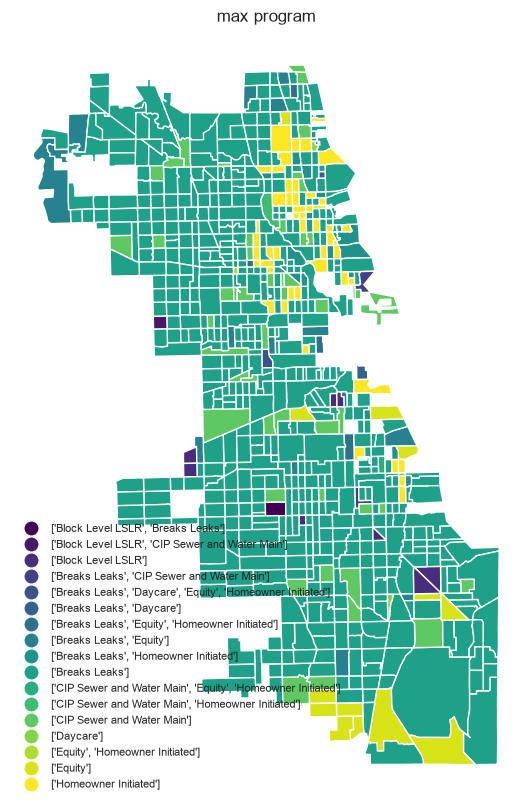

In [242]:
fig, ax = plt.subplots(figsize=(16, 10))

dft_map.plot(
    ax=ax,
    column='maxes_str',
    cmap='viridis',
    legend=True,
    categorical=True,   # force discrete legend
    legend_kwds={
        "loc": "lower left",   # position
        "fontsize": 8,         # shrink text
        "frameon": False       # remove legend box
    }
)

ax.set_title('max program')
ax.axis('off')
plt.show()